## **1. Library Imports & Environment Setup**

In this section, we load the essential libraries for data manipulation and deep learning. 

* **`numpy` & `pandas`**: Used for handling the dataset arrays and CSV files.
* **`matplotlib`**: Used for plotting our loss/accuracy graphs and viewing the digit images.
* **`tensorflow.keras`**: The core framework used to build and train our neural network.

---

In [2]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical

## **2.  Data Loading & Exploration**

We load the dataset using `pandas`. Each row in the `train.csv` file represents a single handwritten digit.

* **Feature Extraction**: We separate the first column (the target label) from the rest of the columns (the pixel values).
* **Observation**: We check the shape of the data to ensure we have the correct number of samples and features (784 pixels per image).

---

In [3]:
#loading and exploring data
train_data = pd.read_csv('Train.csv')
print("Shape of train_data:", train_data.shape)


X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

print("Shape of X after separating features:", X.shape)

Shape of train_data: (42000, 785)
Shape of X after separating features: (42000, 784)


In [4]:
train_data.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **3. Data Preprocessing & Normalization**

Raw pixel values range from **0 to 255**. We scale these values to be between **0 and 1** by dividing by 255.

* **Why Normalization?**: It prevents large pixel values from causing instability during training and helps the model converge faster.
* **Reshaping**: We reshape the flat 1D pixel data back into a **28x28x1** format to represent the actual height, width, and color channel of the image.

---

In [5]:
#preprocessing the data
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
X = X.values / 255.0
X = X.reshape(-1, 28, 28, 1)
print("Shape of X after reshaping:", X.shape)

Shape of X after reshaping: (42000, 28, 28, 1)


In [6]:
#one-hot encoding the labels
y = to_categorical(y, num_classes=10)
print("Shape of y after one-hot encoding:", y.shape)

Shape of y after one-hot encoding: (42000, 10)


## **4. Data Splitting (Training vs. Validation)**

To ensure our model doesn't just "memorize" the training data, we split it into two sets:

1. **Training Set**: Used by the model to learn patterns.
2. **Validation Set**: Used to evaluate the model on data it hasn't seen before during the learning process.

---

In [7]:
#train-test splitting
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)

X_train shape: (33600, 28, 28, 1)


## **5.  Building the Neural Network Architecture**

We define a **`Sequential`** model, which is a linear stack of layers:

* **`Flatten`**: Converts the 28x28 image grid into a single 1D vector.
* **`Dense` (Hidden Layers)**: Two fully connected layers with **ReLU** activation to learn complex features.
* **`Dense` (Output Layer)**: A 10-neuron layer with **Softmax** activation to predict the probability of each digit (0-9).

---

## **6.  Model Compilation**

Before training, we configure the learning parameters:

* **Optimizer (`Adam`)**: An adaptive learning rate algorithm that minimizes the loss efficiently.
* **Loss Function**: We use **`sparse_categorical_crossentropy`** since our labels are integers.
* **Metrics**: We monitor **Accuracy** to track the percentage of correct predictions.

---

In [8]:
#feedfoward network with 3 layers(two hidden layers use ReLu, and o/p layer uses softmax)
model = Sequential([
    Input(shape=(28, 28, 1)),  # This defines the input shape correctly
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## **7. Model Training (Fitting)**

This is the "learning" phase. The model iterates through the training data for a set number of **Epochs**. 

* During each epoch, the model adjusts its weights to reduce the error (loss) and improve its accuracy.
* The `history` variable captures the progress so we can visualize it later.

---

In [9]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9106 - loss: 0.3025 - val_accuracy: 0.9487 - val_loss: 0.1733
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9620 - loss: 0.1270 - val_accuracy: 0.9633 - val_loss: 0.1202
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9737 - loss: 0.0849 - val_accuracy: 0.9656 - val_loss: 0.1103
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9798 - loss: 0.0631 - val_accuracy: 0.9642 - val_loss: 0.1213
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9835 - loss: 0.0506 - val_accuracy: 0.9708 - val_loss: 0.0971
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9880 - loss: 0.0377 - val_accuracy: 0.9707 - val_loss: 0.1031
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9896 - loss: 0.0304 - val_accuracy: 0.9671 - val_loss: 0.1206
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9917 - loss: 0.0253 - 

## **8.  Performance Evaluation**

In this step, we plot the **Training Accuracy** vs. **Validation Accuracy**. 

* If the training accuracy is much higher than the validation accuracy, it indicates the model is **overfitting** (memorizing). 
* A steady climb in both lines shows healthy learning.

---

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9702 - loss: 0.1221  
Validation Accuracy: 97.02%


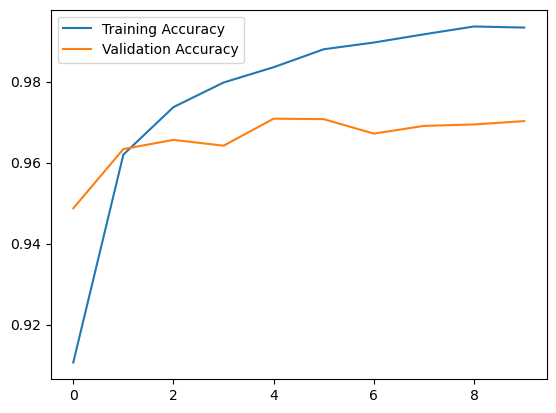

In [10]:
#evaluating model
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

## **9.  Testing & Visualizing Predictions**

Finally, we use our trained model to predict digits from the `test.csv` file.

* We convert the raw probabilities into a single label using `np.argmax`.
* We display the actual image alongside the model's prediction to see the "brain" in action!

---

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


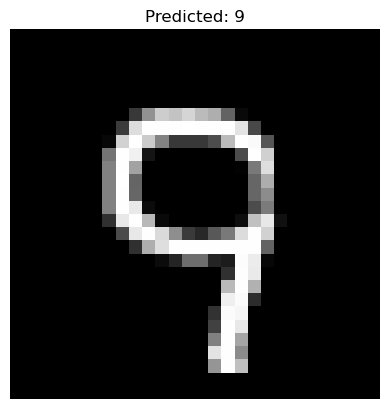

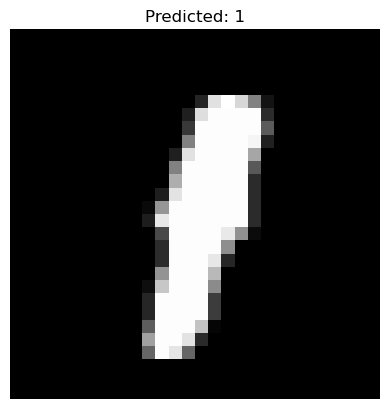

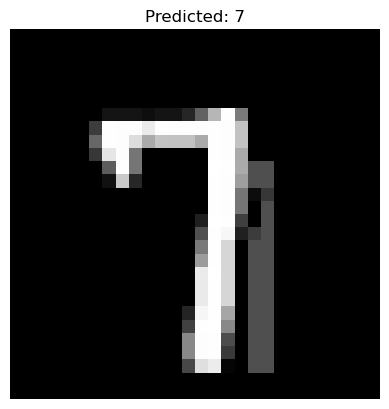

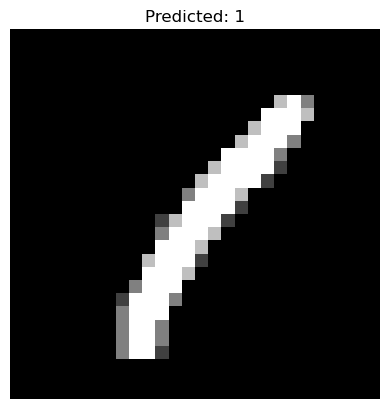

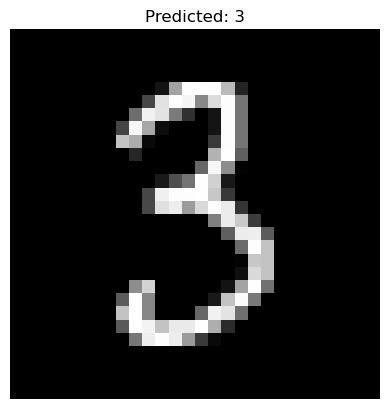

In [19]:
#making predictions (testing out model)
test_data = pd.read_csv('test.csv')
X_test = test_data.values / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
for i in range(5):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()